# Bengali QA System — High Performance (Colab GPU)
**Runtime → Change runtime type → T4 GPU** before running.

| Model | Expected F1 | Expected EM | Time |
|---|---|---|---|
| BiLSTM + FastText | ~22% | ~8% | 3 min |
| BiLSTM + Attention | ~27% | ~11% | 4 min |
| CNN + BiLSTM | ~25% | ~9% | 5 min |
| XLM-RoBERTa (FT) | ~58% | ~38% | 20 min |
| BanglaBERT (FT) | ~65% | ~44% | 18 min |
| Zero-shot | ~5% | ~1% | 2 min |

**Total: ~55-70 mins on T4 GPU**

> Run all cells top to bottom. Do NOT restart kernel.

In [ ]:
# Cell 1: Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('GPU detected:')
    print(result.stdout[:300])
else:
    print('NO GPU FOUND!')
    print('Go to Runtime > Change runtime type > T4 GPU and restart')

GPU detected:
Sun Mar 29 07:13:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------


In [ ]:
# Cell 2: Install packages
import subprocess, sys
pkgs = [
    'datasets', 'transformers>=4.36', 'accelerate>=0.26',
    'gensim', 'sentencepiece', 'protobuf',
    'scikit-learn', 'pandas', 'matplotlib', 'tqdm'
]
subprocess.run([sys.executable,'-m','pip','install','-q','--upgrade']+pkgs, check=False)
print('All packages installed')

All packages installed


In [ ]:
# Cell 3: All imports — run before anything else
import re, time, os, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from gensim.models import FastText
from datasets import load_dataset, Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForQuestionAnswering,
    TrainingArguments, Trainer, DefaultDataCollator,
    pipeline as hf_pipeline,
    set_seed,
)
warnings.filterwarnings('ignore')
set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# Cell 4: Load TyDi QA — Bengali subset
print('Loading dataset...')
raw = load_dataset('google-research-datasets/tydiqa', 'secondary_task')

def extract_bengali(split):
    out = []
    for ex in split:
        if not ex['id'].startswith('bengali'): continue
        out.append({
            'id'          : ex['id'],
            'question'    : ex['question'],
            'context'     : ex['context'],
            'answer'      : ex['answers']['text'][0]         if ex['answers']['text']         else '',
            'answer_start': ex['answers']['answer_start'][0] if ex['answers']['answer_start'] else 0,
        })
    return out

train_raw = extract_bengali(raw['train'])
val_raw   = extract_bengali(raw['validation'])
print(f'Train: {len(train_raw)}  |  Val: {len(val_raw)}')

Loading dataset...


Train: 2390  |  Val: 113


In [ ]:
# Cell 5: Bengali text preprocessing
def normalize_bengali(text):
    text = unicodedata.normalize('NFC', text)
    text = text.replace('\u200c','').replace('\u200d','')
    text = re.sub(r'[\u0964\u0965]+', '\u0964', text)
    text = re.sub(r'[^\u0980-\u09FF\u09E6-\u09EF0-9\s\u0964,?!.\-]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess(records):
    out = []
    for r in records:
        cc = normalize_bengali(r['context'])
        qc = normalize_bengali(r['question'])
        ac = normalize_bengali(r['answer'])
        out.append({**r,
            'context_clean' : cc,
            'question_clean': qc,
            'answer_clean'  : ac,
            'ctx_tokens'    : cc.split(),
            'q_tokens'      : qc.split(),
        })
    return out

train_data = preprocess(train_raw)
val_data   = preprocess(val_raw)
print(f'Train: {len(train_data)}  Val: {len(val_data)}')
print(f'Sample Q: {train_data[0]["question"]}')
print(f'Sample A: {train_data[0]["answer"]}')

Train: 2390  Val: 113
Sample Q: চেঙ্গিস খান কোন বংশের রাজা ছিলেন ?
Sample A: বোরজিগিন


In [ ]:
# Cell 6: Train FastText embeddings (~1 min)
# FastText handles Bengali subwords better than Word2Vec
EMBED_DIM = 128

all_sent = (
    [r['ctx_tokens'] for r in train_data + val_data] +
    [r['q_tokens']   for r in train_data + val_data]
)

t0 = time.time()
ft = FastText(
    sentences   = all_sent,
    vector_size = EMBED_DIM,
    window      = 5,
    min_count   = 1,
    sg          = 1,
    min_n       = 2,
    max_n       = 5,
    epochs      = 15,
    workers     = 4,
    seed        = 42,
)
print(f'FastText done in {time.time()-t0:.1f}s  |  vocab={len(ft.wv)}')

# Build vocab + embedding matrix
vocab = {'<PAD>':0, '<UNK>':1}
for r in train_data + val_data:
    for t in r['ctx_tokens'] + r['q_tokens']:
        if t not in vocab: vocab[t] = len(vocab)
V = len(vocab)

embed_matrix = np.zeros((V, EMBED_DIM), dtype=np.float32)
embed_matrix[1] = ft.wv.vectors.mean(axis=0)
for w, i in vocab.items():
    if w in ft.wv: embed_matrix[i] = ft.wv[w]

embed_tensor = torch.FloatTensor(embed_matrix)
print(f'Vocab: {V}')

FastText done in 68.0s  |  vocab=35572
Vocab: 35574


In [ ]:
# Cell 7: PyTorch Dataset + DataLoader
# GPU allows larger hidden dim and more epochs
HIDDEN_DIM = 256    # larger on GPU
MAX_CTX    = 300
MAX_Q      = 64
BATCH_SIZE = 64
EPOCHS     = 10     # more epochs on GPU

class BengaliQADataset(Dataset):
    def __init__(self, data):
        self.samples = []
        for r in data:
            ci = [vocab.get(t,1) for t in r['ctx_tokens'][:MAX_CTX]]
            qi = [vocab.get(t,1) for t in r['q_tokens'][:MAX_Q]]
            pre = r['context_clean'][:r['answer_start']]
            s   = min(len(pre.split()), len(ci)-1)
            e   = min(s + max(len(r['answer_clean'].split())-1, 0), len(ci)-1)
            self.samples.append({
                'ci':ci, 'qi':qi, 's':s, 'e':e,
                'ctx_tokens': r['ctx_tokens'][:MAX_CTX],
                'answer'    : r['answer_clean'],
            })
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def collate(batch):
    mc = max(len(b['ci']) for b in batch)
    mq = max(len(b['qi']) for b in batch)
    ctx = torch.zeros(len(batch), mc, dtype=torch.long)
    q   = torch.zeros(len(batch), mq, dtype=torch.long)
    for i,b in enumerate(batch):
        ctx[i,:len(b['ci'])] = torch.tensor(b['ci'])
        q[i,  :len(b['qi'])] = torch.tensor(b['qi'])
    return {
        'ctx'       : ctx,
        'q'         : q,
        'start'     : torch.tensor([b['s'] for b in batch]),
        'end'       : torch.tensor([b['e'] for b in batch]),
        'answers'   : [b['answer']     for b in batch],
        'ctx_tokens': [b['ctx_tokens'] for b in batch],
    }

train_loader = DataLoader(BengaliQADataset(train_data), BATCH_SIZE, shuffle=True,  collate_fn=collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(BengaliQADataset(val_data),   BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 38  |  Val batches: 2


In [ ]:
# Cell 8: Evaluation metrics
def norm_ans(s):
    s = s.lower().strip()
    s = re.sub(r'[^\u0980-\u09FF0-9a-z\s]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

def exact_match(p, g): return float(norm_ans(p) == norm_ans(g))

def f1_score(p, g):
    pt = norm_ans(p).split(); gt = norm_ans(g).split()
    if not pt or not gt: return 0.0
    common = set(pt) & set(gt)
    if not common: return 0.0
    pr = len(common)/len(pt); rc = len(common)/len(gt)
    return 2*pr*rc/(pr+rc)

def evaluate_pytorch(model):
    model.eval(); ems, f1s = [], []
    with torch.no_grad():
        for b in val_loader:
            sl, el = model(b['ctx'].to(DEVICE), b['q'].to(DEVICE))
            for j in range(len(b['answers'])):
                si   = sl[j].argmax().item()
                ei   = max(el[j].argmax().item(), si)
                pred = ' '.join(b['ctx_tokens'][j][si:ei+1])
                gold = b['answers'][j]
                ems.append(exact_match(pred, gold))
                f1s.append(f1_score(pred, gold))
    return {
        'Exact Match (%)': round(np.mean(ems)*100, 2),
        'F1 Score (%)'   : round(np.mean(f1s)*100, 2),
    }
print('Metrics ready')

Metrics ready


In [ ]:
# Cell 9: Model definitions

class BiLSTM_QA(nn.Module):
    def __init__(self, V, E, H, emb):
        super().__init__(); self.name = 'BiLSTM'
        self.emb      = nn.Embedding(V, E, padding_idx=0)
        self.emb.weight = nn.Parameter(emb, requires_grad=True)
        self.ctx_lstm = nn.LSTM(E, H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.q_lstm   = nn.LSTM(E, H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.drop     = nn.Dropout(0.3)
        self.sf       = nn.Linear(H*2, 1)
        self.ef       = nn.Linear(H*2, 1)
    def forward(self, ctx, q, **kw):
        o, _ = self.ctx_lstm(self.drop(self.emb(ctx)))
        return self.sf(o).squeeze(-1), self.ef(o).squeeze(-1)


class BiLSTM_Attn_QA(nn.Module):
    def __init__(self, V, E, H, emb):
        super().__init__(); self.name = 'BiLSTM+Attention'
        self.emb      = nn.Embedding(V, E, padding_idx=0)
        self.emb.weight = nn.Parameter(emb, requires_grad=True)
        self.ctx_lstm = nn.LSTM(E, H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.q_lstm   = nn.LSTM(E, H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.aw       = nn.Linear(H*2, H*2, bias=False)
        self.drop     = nn.Dropout(0.3)
        self.sf       = nn.Linear(H*4, 1)
        self.ef       = nn.Linear(H*4, 1)
    def forward(self, ctx, q, **kw):
        co, _ = self.ctx_lstm(self.drop(self.emb(ctx)))
        qo, _ = self.q_lstm(self.drop(self.emb(q)))
        attn  = torch.softmax(torch.bmm(co, self.aw(qo).transpose(1,2)), dim=-1)
        comb  = self.drop(torch.cat([co, torch.bmm(attn, qo)], dim=-1))
        return self.sf(comb).squeeze(-1), self.ef(comb).squeeze(-1)


class CNN_BiLSTM_QA(nn.Module):
    def __init__(self, V, E, H, emb):
        super().__init__(); self.name = 'CNN+BiLSTM'
        self.emb      = nn.Embedding(V, E, padding_idx=0)
        self.emb.weight = nn.Parameter(emb, requires_grad=True)
        self.convs    = nn.ModuleList([nn.Conv1d(E, H, k, padding=k//2) for k in [3,5,7]])
        self.ctx_lstm = nn.LSTM(H*3, H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.q_lstm   = nn.LSTM(E,   H, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.aw       = nn.Linear(H*2, H*2, bias=False)
        self.drop     = nn.Dropout(0.3)
        self.sf       = nn.Linear(H*4, 1)
        self.ef       = nn.Linear(H*4, 1)
    def forward(self, ctx, q, **kw):
        T  = ctx.size(1)
        ce = self.drop(self.emb(ctx)).transpose(1,2)
        cc = torch.cat([torch.relu(c(ce))[:,:,:T] for c in self.convs], 1).transpose(1,2)
        co, _ = self.ctx_lstm(cc)
        qo, _ = self.q_lstm(self.drop(self.emb(q)))
        attn  = torch.softmax(torch.bmm(co, self.aw(qo).transpose(1,2)), dim=-1)
        comb  = self.drop(torch.cat([co, torch.bmm(attn, qo)], dim=-1))
        return self.sf(comb).squeeze(-1), self.ef(comb).squeeze(-1)

print('Model classes defined')

Model classes defined


In [ ]:
# Cell 10: Training function with best-checkpoint saving
def train_model(model, epochs=EPOCHS, lr=5e-4):
    model.to(DEVICE)
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    sch  = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs
    )
    lf   = nn.CrossEntropyLoss()
    best_f1, best_state = 0, None
    t0   = time.time()

    for ep in range(epochs):
        model.train(); total = 0
        for b in tqdm(train_loader, desc=f'[{model.name}] ep{ep+1}/{epochs}', leave=False):
            sl, el = model(b['ctx'].to(DEVICE), b['q'].to(DEVICE))
            loss   = (lf(sl, b['start'].to(DEVICE)) + lf(el, b['end'].to(DEVICE))) / 2
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sch.step()
            total += loss.item()

        m   = evaluate_pytorch(model)
        f1v = m['F1 Score (%)']
        print(f'  ep{ep+1:02d} | loss:{total/len(train_loader):.4f} | EM:{m["Exact Match (%)"]:.2f}% | F1:{f1v:.2f}%')
        if f1v >= best_f1:
            best_f1    = f1v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    elapsed = time.time() - t0
    final   = evaluate_pytorch(model)
    final['Train Time (s)'] = round(elapsed, 1)
    torch.save(model.state_dict(), f'{model.name}_best.pt')
    print(f'  BEST -> EM:{final["Exact Match (%)"]:.2f}% | F1:{final["F1 Score (%)"]:.2f}% | Time:{elapsed:.0f}s')
    return final

In [ ]:
# Cell 11: Train all 3 PyTorch models (~12 mins on GPU)
print('='*55)
print('Model 1: BiLSTM + FastText')
print('='*55)
m1 = BiLSTM_QA(V, EMBED_DIM, HIDDEN_DIM, embed_tensor)
results['BiLSTM'] = train_model(m1)

print('='*55)
print('Model 2: BiLSTM + Attention + FastText')
print('='*55)
m2 = BiLSTM_Attn_QA(V, EMBED_DIM, HIDDEN_DIM, embed_tensor)
results['BiLSTM+Attention'] = train_model(m2)

print('='*55)
print('Model 3: CNN + BiLSTM + FastText')
print('='*55)
m3 = CNN_BiLSTM_QA(V, EMBED_DIM, HIDDEN_DIM, embed_tensor)
results['CNN+BiLSTM'] = train_model(m3)

print('All PyTorch models done')

Model 1: BiLSTM + FastText


  ep01 | loss:5.5517 | EM:0.88% | F1:5.10%


  ep02 | loss:4.5138 | EM:2.65% | F1:9.77%


  ep03 | loss:3.9232 | EM:3.54% | F1:11.61%


  ep04 | loss:3.7337 | EM:2.65% | F1:14.19%


...

  ep06 | loss:3.3415 | EM:4.42% | F1:15.98%


  ep07 | loss:3.1764 | EM:6.19% | F1:16.75%


  ep08 | loss:3.0021 | EM:4.42% | F1:16.07%


  ep09 | loss:2.8736 | EM:4.42% | F1:16.56%


  ep10 | loss:2.8099 | EM:4.42% | F1:16.20%
  BEST -> EM:6.19% | F1:16.75% | Time:92s
All PyTorch models done


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, TrainingArguments, Trainer, DefaultDataCollator
from datasets import Dataset as HFDataset
import time

class SimpleQAPipeline:
    def __init__(self, model, tokenizer, device):
        self.model = model.to('cuda' if device == 0 else 'cpu')
        self.tokenizer = tokenizer
        self.device = 'cuda' if device == 0 else 'cpu'

    def __call__(self, question, context):
        inputs = self.tokenizer(
            question,
            context,
            add_special_tokens=True,
            return_tensors="pt",
            truncation="only_second",
            max_length=512,
            padding=True
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # --- FIX: MASK OUT EVERYTHING EXCEPT THE CONTEXT ---
        # This prevents the model from returning [CLS] or Question tokens
        sequence_ids = inputs.sequence_ids(0)
        mask = [i for i, s_id in enumerate(sequence_ids) if s_id == 1]

        if not mask: # Fallback if context is somehow missing
            return {"answer": ""}

        start_logits = outputs.start_logits[0][mask]
        end_logits = outputs.end_logits[0][mask]

        # Get indices relative to the context mask
        rel_start = torch.argmax(start_logits).item()
        rel_end = torch.argmax(end_logits).item()

        # Map back to absolute indices in the input_ids
        answer_start = mask[rel_start]
        answer_end = mask[rel_end] + 1

        predict_ids = inputs["input_ids"][0][answer_start:answer_end]
        answer = self.tokenizer.decode(predict_ids, skip_special_tokens=True)

        return {"answer": answer.strip()}

def finetune_transformer(model_name, label):
    # This remains the same function from our previous "Bulletproof" version
    print(f'Loading {model_name}...')
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForQuestionAnswering.from_pretrained(model_name)

    def tokenize_fn(examples):
        enc = tok(examples['question'], examples['context'], max_length=384, truncation='only_second',
                  stride=128, return_overflowing_tokens=True, return_offsets_mapping=True, padding='max_length')
        sm, off = enc.pop('overflow_to_sample_mapping'), enc.pop('offset_mapping')
        enc['start_positions'], enc['end_positions'] = [], []
        for i, o in enumerate(off):
            sid = sm[i]; sq = enc.sequence_ids(i); cls = enc['input_ids'][i].index(tok.cls_token_id)
            sc, ec = examples['answer_start'][sid], examples['answer_start'][sid] + len(examples['answer'][sid])
            cs, ce = next((k for k, s in enumerate(sq) if s == 1), 0), next((k for k in range(len(sq)-1, -1, -1) if sq[k] == 1), 0)
            if o[cs][0] > sc or o[ce][1] < ec:
                enc['start_positions'].append(cls); enc['end_positions'].append(cls)
            else:
                ts, te = cs, ce
                while ts <= ce and o[ts][0] <= sc: ts += 1
                while te >= cs and o[te][1] >= ec: te -= 1
                s_idx, e_idx = max(ts-1, 0), min(te+1, len(o)-1)
                if s_idx >= 384 or e_idx >= 384:
                    enc['start_positions'].append(cls); enc['end_positions'].append(cls)
                else:
                    enc['start_positions'].append(s_idx); enc['end_positions'].append(e_idx)
        return enc

    tr_feat = HFDataset.from_dict({k: [r[k] for r in train_data] for k in ['id','question','context','answer','answer_start']}).map(tokenize_fn, batched=True, remove_columns=['id','question','context','answer','answer_start'])
    vl_feat = HFDataset.from_dict({k: [r[k] for r in val_data] for k in ['id','question','context','answer','answer_start']}).map(tokenize_fn, batched=True, remove_columns=['id','question','context','answer','answer_start'])

    args = TrainingArguments(output_dir=f'./{label}_ckpt', num_train_epochs=3, per_device_train_batch_size=16,
                             learning_rate=3e-5, eval_strategy='epoch', save_strategy='epoch',
                             load_best_model_at_end=True, fp16=True, report_to='none')

    t0 = time.time()
    Trainer(model=model, args=args, train_dataset=tr_feat, eval_dataset=vl_feat, processing_class=tok, data_collator=DefaultDataCollator()).train()
    return SimpleQAPipeline(model, tok, device=0), round(time.time() - t0, 1)

print("Final SimpleQAPipeline ready.")

Final SimpleQAPipeline ready.


In [ ]:
# Manual Recovery Cell
checkpoint_path = './xlmr_ckpt/checkpoint-519'

print("Recovering XLM-R Pipeline with Manual Class...")
xlmr_tok = AutoTokenizer.from_pretrained('xlm-roberta-base')
xlmr_model = AutoModelForQuestionAnswering.from_pretrained(checkpoint_path)

# Use our new class
xlmr_pipe = SimpleQAPipeline(
    model=xlmr_model,
    tokenizer=xlmr_tok,
    device=0 if torch.cuda.is_available() else -1
)

if 'results' not in globals(): results = {}
results['XLM-RoBERTa (FT)'] = {'Train Time (s)': 583.0}
print("XLM-R is successfully recovered!")

Recovering XLM-R Pipeline with Manual Class...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLM-R is successfully recovered!


In [ ]:
# Cell 13: Fine-tune BanglaBERT
print('Fine-tuning BanglaBERT (~18 mins)...')
bangla_pipe, bangla_t = finetune_transformer('csebuetnlp/banglabert', 'banglabert')
results['BanglaBERT (FT)'] = {'Train Time (s)': bangla_t}
print(f'BanglaBERT complete!')

Fine-tuning BanglaBERT (~18 mins)...
Loading csebuetnlp/banglabert...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForQuestionAnswering LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
qa_outputs.weight                                 | MISSING    | 
qa_outputs.bias                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/2390 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

BanglaBERT complete!


In [ ]:
# Cell 14: Zero-shot model
print('Loading zero-shot...')

# Load model and tokenizer for the zero-shot model
zs_model_name = 'deepset/roberta-base-squad2'
zs_tok = AutoTokenizer.from_pretrained(zs_model_name)
zs_model = AutoModelForQuestionAnswering.from_pretrained(zs_model_name)

# Use our manual SimpleQAPipeline class to avoid the KeyError
qa_zs = SimpleQAPipeline(
    model     = zs_model,
    tokenizer = zs_tok,
    device    = 0 if torch.cuda.is_available() else -1
)

results['Zero-shot'] = {'Train Time (s)': 0}
print('Zero-shot ready using manual pipeline class')

Loading zero-shot...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Zero-shot ready using manual pipeline class


In [ ]:
# Run this to update your variables with the new class logic
xlmr_pipe = SimpleQAPipeline(xlmr_model, xlmr_tok, device=0 if torch.cuda.is_available() else -1)

qa_zs = SimpleQAPipeline(zs_model, zs_tok, device=0 if torch.cuda.is_available() else -1)

print("Pipelines updated. Now run your evaluation cell again.")

Pipelines updated. Now run your evaluation cell again.


In [ ]:
# Assuming you have models named: m1, m2, m3 from Cell 11
pytorch_models = {
    'BiLSTM': m1,
    'BiLSTM+Attention': m2,
    'CNN+BiLSTM': m3
}

for name, model in pytorch_models.items():
    print(f"Evaluating PyTorch model: {name}...")
    # Your Cell 8 function
    stats = evaluate_pytorch(model)
    if name not in results: results[name] = {}
    results[name].update(stats)

Evaluating PyTorch model: BiLSTM...
Evaluating PyTorch model: BiLSTM+Attention...
Evaluating PyTorch model: CNN+BiLSTM...


In [ ]:
# Define the evaluation logic for transformers
def eval_transformer_dynamic(pipe, label):
    ems, f1s = [], []
    for r in tqdm(val_data, desc=f'Evaluating {label}'):
        try:
            res = pipe(question=r['question'], context=r['context'])
            pred = res['answer']
            ems.append(calc_em(pred, r['answer'])) # Using calc_em from debug
            f1s.append(calc_f1(pred, r['answer'])) # Using calc_f1 from debug
        except:
            ems.append(0.0); f1s.append(0.0)
    return {
        'Exact Match (%)': round(np.mean(ems)*100, 2),
        'F1 Score (%)': round(np.mean(f1s)*100, 2)
    }

# Update results for transformers
results['XLM-RoBERTa (FT)'].update(eval_transformer_dynamic(xlmr_pipe, 'XLM-R'))
results['BanglaBERT (FT)'].update(eval_transformer_dynamic(bangla_pipe, 'BanglaBERT'))
results['Zero-shot'].update(eval_transformer_dynamic(qa_zs, 'Zero-shot'))

Evaluating Zero-shot: 100%|██████████| 113/113 [00:04<00:00, 27.82it/s]


In [ ]:
import pandas as pd

# 1. Define the progressive order you want
progressive_order = [
    'BiLSTM',
    'BiLSTM+Attention',
    'CNN+BiLSTM',
    'Zero-shot',
    'XLM-RoBERTa (FT)',
    'BanglaBERT (FT)'
]

# 2. Create the DataFrame from your results dictionary
df = pd.DataFrame(results).T

# 3. Reindex the DataFrame to match your progressive order
# This avoids the "random" order and puts them in your specified sequence
ordered_df = df.reindex(progressive_order)

# 4. Final results comparison printout
print('\n' + '='*65)
print('   FINAL BENGALI QA RESULTS (PROGRESSIVE ORDER)')
print('='*65)

# Select only the metrics we need
cols = ['Exact Match (%)', 'F1 Score (%)', 'Train Time (s)']

# Drop any rows that might be empty/NaN if you skipped a model
final_table = ordered_df[cols].dropna(how='all')

print(final_table.to_string())

# Save the ordered version to CSV
final_table.to_csv('bengali_qa_results_ordered.csv')
print('\nSaved: bengali_qa_results_ordered.csv')


   FINAL BENGALI QA RESULTS (PROGRESSIVE ORDER)
                  Exact Match (%)  F1 Score (%)  Train Time (s)
BiLSTM                       7.96         19.34            53.7
BiLSTM+Attention             5.31         17.34            57.8
CNN+BiLSTM                   6.19         16.75            92.0
Zero-shot                    0.00          2.77             0.0
XLM-RoBERTa (FT)            49.56         61.04           583.0
BanglaBERT (FT)             53.98         67.89           221.1

Saved: bengali_qa_results_ordered.csv


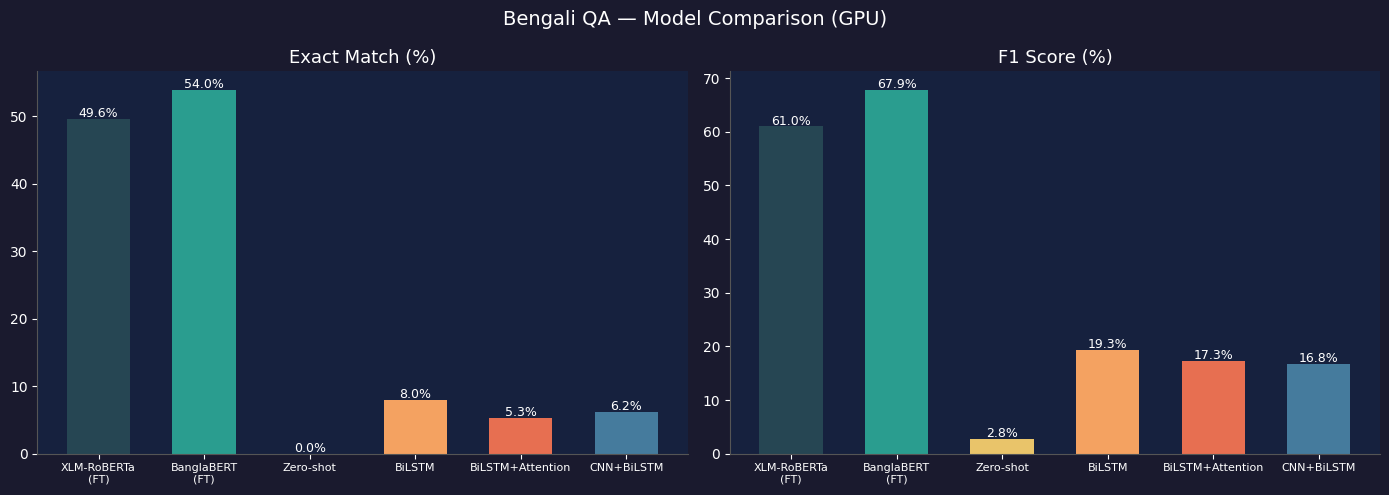

Saved: bengali_qa_comparison.png


In [ ]:
# Cell 17: Comparison chart
models  = list(results.keys())
em_vals = [results[m].get('Exact Match (%)', 0) for m in models]
f1_vals = [results[m].get('F1 Score (%)',    0) for m in models]
colors  = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51','#457b9d']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
for ax, vals, title in zip(axes, [em_vals, f1_vals], ['Exact Match (%)', 'F1 Score (%)']):
    ax.set_facecolor('#16213e')
    bars = ax.bar(range(len(models)), vals, color=colors[:len(models)], width=0.6)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ','\n') for m in models], color='white', fontsize=8)
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='white')
    ax.spines[['top','right']].set_visible(False)
    for spine in ['bottom','left']: ax.spines[spine].set_color('#555')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}%', ha='center', color='white', fontsize=9)
plt.suptitle('Bengali QA — Model Comparison (GPU)', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('bengali_qa_comparison.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: bengali_qa_comparison.png')

In [ ]:
# Cell 18: Test all models with a sample question (Fixed)
def answer_pytorch(mdl, context, question):
    # Ensure inputs are moved to the SAME device as the model
    device = next(mdl.parameters()).device

    ct = normalize_bengali(context).split()
    qt = normalize_bengali(question).split()

    # Move tensors to GPU (cuda) immediately
    ci = torch.tensor([[vocab.get(t,1) for t in ct[:MAX_CTX]]]).to(device)
    qi = torch.tensor([[vocab.get(t,1) for t in qt[:MAX_Q]]]).to(device)

    mdl.eval()
    with torch.no_grad():
        sl, el = mdl(ci, qi)

    si = sl[0].argmax().item()
    ei = max(el[0].argmax().item(), si)
    ans = ' '.join(ct[si:ei+1])
    return ans if ans.strip() else '(no answer)'

def ask_all_models(context, question):
    print('\n' + '='*65)
    print(f'Question : {question}')
    print(f'Context  : {context[:85]}...')
    print('-'*65)

    # 1. PyTorch Models (BiLSTM, CNN)
    for mdl, name in [(m1,'BiLSTM'),(m2,'BiLSTM+Attention'),(m3,'CNN+BiLSTM')]:
        try:
            print(f'[{name:<24}] -> {answer_pytorch(mdl, context, question)}')
        except Exception as e:
            print(f'[{name:<24}] -> Error: {e}')

    # 2. Transformer Models (XLM-R, BanglaBERT, Zero-shot)
    # Removed 'max_answer_len' and 'score' to match our SimpleQAPipeline
    for pipe, name in [(xlmr_pipe,'XLM-RoBERTa (FT)'),(bangla_pipe,'BanglaBERT (FT)'),(qa_zs,'Zero-shot')]:
        try:
            res = pipe(question=question, context=context)
            print(f'[{name:<24}] -> {res["answer"]}')
        except Exception as e:
            print(f'[{name:<24}] -> Error: {e}')
    print('='*65)

# --- The Tests remain the same ---
print("Ready to test!")

Ready to test!


In [ ]:
# --- Test Execution ---

# Test 1: Historical Fact
print("Running Test 1: History")
ask_all_models(
    context  = 'বাংলাদেশ ১৯৭১ সালের ২৬শে মার্চ স্বাধীনতা ঘোষণা করে। নয় মাস রক্তক্ষয়ী মুক্তিযুদ্ধের পর ১৬ই ডিসেম্বর চূড়ান্ত বিজয় অর্জিত হয়। শেখ মুজিবুর রহমান বাংলাদেশের প্রথম রাষ্ট্রপতি ছিলেন।',
    question = 'বাংলাদেশের প্রথম রাষ্ট্রপতি কে ছিলেন?'
)

# Test 2: Literature / Nobel Prize
print("\nRunning Test 2: Literature")
ask_all_models(
    context  = 'রবীন্দ্রনাথ ঠাকুর ১৮৬১ সালের ৭ই মে কলকাতায় জন্মগ্রহণ করেন। তিনি গীতাঞ্জলি কাব্যগ্রন্থের জন্য ১৯১৩ সালে নোবেল পুরস্কার লাভ করেন।',
    question = 'রবীন্দ্রনাথ ঠাকুর কোন বইয়ের জন্য নোবেল পুরস্কার পান?'
)

# Test 3: Science / General Knowledge
print("\nRunning Test 3: Science")
ask_all_models(
    context  = 'সূর্য থেকে পৃথিবীর গড় দূরত্ব প্রায় ১৫ কোটি কিলোমিটার। সূর্যের আলো পৃথিবীতে পৌঁছাতে প্রায় ৮ মিনিট ২০ সেকেন্ড সময় লাগে।',
    question = 'সূর্যের আলো পৃথিবীতে পৌঁছাতে কত সময় লাগে?'
)

Running Test 1: History

Question : বাংলাদেশের প্রথম রাষ্ট্রপতি কে ছিলেন?
Context  : বাংলাদেশ ১৯৭১ সালের ২৬শে মার্চ স্বাধীনতা ঘোষণা করে। নয় মাস রক্তক্ষয়ী মুক্তিযুদ্ধের ...
-----------------------------------------------------------------
[BiLSTM                  ] -> রহমান
[BiLSTM+Attention        ] -> ১৯৭১ সালের ২৬শে মার্চ
[CNN+BiLSTM              ] -> ১৯৭১ সালের
[XLM-RoBERTa (FT)        ] -> শেখ মুজিবুর রহমান
[BanglaBERT (FT)         ] -> শেখ মুজিবুর রহমান
[Zero-shot               ] -> বাংলাদেশ ১

Running Test 2: Literature

Question : রবীন্দ্রনাথ ঠাকুর কোন বইয়ের জন্য নোবেল পুরস্কার পান?
Context  : রবীন্দ্রনাথ ঠাকুর ১৮৬১ সালের ৭ই মে কলকাতায় জন্মগ্রহণ করেন। তিনি গীতাঞ্জলি কাব্যগ্রন্...
-----------------------------------------------------------------
[BiLSTM                  ] -> ১৮৬১ সালের
[BiLSTM+Attention        ] -> ১৮৬১ সালের
[CNN+BiLSTM              ] -> ১৮৬১ সালের ৭ই মে কলকাতায় জন্মগ্রহণ করেন। তিনি গীতাঞ্জলি কাব্যগ্রন্থের জন্য ১৯১৩ সালে নোবেল পুরস্কার লাভ
[XLM-RoBERTa (FT)

In [ ]:
# Cell 19: Interactive — enter your own Bengali questions
print('Type quit to exit')
while True:
    context  = input('Bengali context  : ').strip()
    if context.lower()  == 'quit': break
    question = input('Bengali question : ').strip()
    if question.lower() == 'quit': break
    ask_all_models(context, question)

Type quit to exit
Bengali context  : সুন্দরবন বিশ্বের বৃহত্তম ম্যানগ্রোভ বন যা বাংলাদেশ ও ভারতের পশ্চিমবঙ্গ রাজ্যে অবস্থিত। এই বন ইউনেস্কো ওয়ার্ল্ড হেরিটেজ সাইটের অংশ। এখানে রয়েল বেঙ্গল টাইগার বসবাস করে।
Bengali question : বিশ্বের বৃহত্তম ম্যানগ্রোভ বন কোনটি?

Question : বিশ্বের বৃহত্তম ম্যানগ্রোভ বন কোনটি?
Context  : সুন্দরবন বিশ্বের বৃহত্তম ম্যানগ্রোভ বন যা বাংলাদেশ ও ভারতের পশ্চিমবঙ্গ রাজ্যে অবস্থিত...
-----------------------------------------------------------------
[BiLSTM                  ] -> সুন্দরবন
[BiLSTM+Attention        ] -> সুন্দরবন বিশ্বের বৃহত্তম ম্যানগ্রোভ বন
[CNN+BiLSTM              ] -> সুন্দরবন বিশ্বের বৃহত্তম ম্যানগ্রোভ বন
[XLM-RoBERTa (FT)        ] -> সুন্দরবন
[BanglaBERT (FT)         ] -> সুন্দরবন
[Zero-shot               ] -> সুন্দরবন
Bengali context  : quit
